# Time-Accurate Rotor with Thrust-Convergence Stopping Criterion

This notebook demonstrates how to configure a **run control stopping criterion** for a time-accurate rotor simulation. The criterion monitors the mean thrust (CFz) averaged over the last two rotor revolutions and halts the simulation automatically once the mean has converged - avoiding manual step-count tuning.

The geometry is the **DTU 10MW reference wind turbine** (blade radius R ≈ 89 m). The setup uses a time-accurate sliding-interface approach, so the physical time step size and maximum number of revolutions are derived from the single parameter `dt_deg`.

Key features covered:
- Project creation from a local CAD geometry file (beta mesher)
- Time-accurate unsteady simulation with a sliding rotating zone
- `ForceOutput` with `MovingStatistic` computing a rolling mean over the last two revolutions
- `RunControl` with a `StoppingCriterion` tied to the rolling-mean thrust output

**Note:** The settings in this example are by no means a validation setup; they are crafted to showcase the capabilities of Flow360 and we have intentionally reduced node count and example FC cost. For rigorous validation, modify the settings as needed.

## 1. Load a Project

Load the Flow360 client and create a new project from the DTU 10MW EGADS geometry file (length unit: metres).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import flow360 as fl
from flow360.examples import DTU_WindTurbine

DTU_WindTurbine.get_files()

project = fl.Project.from_geometry(
    DTU_WindTurbine.geometry, length_unit="m", name="DTU Wind Turbine stopping-criterion tutorial"
)
geometry = project.geometry

Output()

[09:58:38] INFO: Geometry successfully submitted:                                                                  
                   type        = Geometry                                                                          
                   name        = DTU Wind Turbine stopping-criterion tutorial                                      
                   id          = geo-f3c47111-91b5-44c0-afd5-a7c3d811fb73                                          
                   status      = uploaded                                                                          
                   project id  = prj-efdd1dbc-c9e4-4d01-895a-cc034e4caae6                                          
           

           INFO: Waiting for geometry to be processed.

Output()

## 2. Geometry Primitives

Define:
- `rotor_cylinder` — the rotating zone encapsulating the rotor blades. This cylinder drives both the sliding-interface mesh zone and the rotation model.
- `wake_cylinder` — a coarser volumetric refinement zone to improve wake resolution.

In [2]:
with fl.SI_unit_system:
    farfield = fl.AutomatedFarfield()

    R = 89.166  # blade radius [m] — DTU 10MW reference turbine

    # Rotating zone: encloses the full rotor disk with margin.
    # Axis along +Z (shaft direction); adjust if your geometry differs.
    rotor_cylinder = fl.Cylinder(
        center=(0, 0, 0),
        outer_radius=110 * fl.u.m,
        height=40 * fl.u.m,
        axis=(0, 0, 1),
        name="RotorCylinder",
    )

    # Wake refinement zone: extends downstream of the rotor.
    wake_cylinder = fl.Cylinder(
        center=(0, 0, 55) * fl.u.m,
        outer_radius=200 * fl.u.m,
        height=200 * fl.u.m,
        axis=(0, 0, 1),
        name="WakeCylinder",
    )

[10:00:03] INFO: using: SI unit system for unit inference.

## 3. Meshing Parameters

The mesh is intentionally coarse — this example focuses on the stopping-criterion workflow, not on high-fidelity aerodynamics. The rotating zone interface controls the mesh density inside `rotor_cylinder`, and a light wake refinement is applied downstream.

In [3]:
rotating_zone = fl.RotationVolume(
    name="RotatingZone",
    spacing_axial=2 * fl.u.m,
    spacing_circumferential=2 * fl.u.m,
    spacing_radial=2 * fl.u.m,
    entities=rotor_cylinder,
    enclosed_entities=geometry["*"],
)

meshing = fl.MeshingParams(
    defaults=fl.MeshingDefaults(
        surface_max_edge_length=2 * fl.u.m,
        boundary_layer_first_layer_thickness=1e-4 * fl.u.m,
    ),
    volume_zones=[farfield, rotating_zone],
    refinements=[
        fl.UniformRefinement(entities=wake_cylinder, spacing=4 * fl.u.m),
        fl.UniformRefinement(entities=rotor_cylinder, spacing=2 * fl.u.m),
    ],
)

## 4. Time Stepping

For a **time-accurate sliding-interface** simulation the time stepping must be `fl.Unsteady`. Using `fl.Rotation` with an unsteady solver activates the sliding-mesh algorithm automatically instead of MRF.

The physical time step size is derived from `dt_deg` and `omega` so that all downstream quantities (`steps_per_rev`, `window_steps`, `tolerance_window_size`) update consistently when either parameter is changed. The run is capped at `revs` revolutions; the stopping criterion (Section 6) will terminate it earlier once thrust has converged.

In [4]:
omega = 8.836 * fl.u.rpm  # rated angular velocity — DTU 10MW
dt_deg = 6.0  # physical time step [degrees]; change as needed
revs = 50  # maximum number of revolutions to simulate
steps_per_rev = int(360 / dt_deg)
step_size = (dt_deg * fl.u.deg / omega.to("deg/s")).to("s")

time_stepping = fl.Unsteady(
    steps=revs * steps_per_rev,
    step_size=step_size,
    max_pseudo_steps=50,
)

rotation = fl.Rotation(
    name="RotatingZone",
    volumes=rotor_cylinder,
    spec=fl.AngularVelocity(omega),
)

## 5. Force Output with Moving Statistic

A `ForceOutput` is configured with a `MovingStatistic` that computes the **rolling mean of CFz over the last two rotor revolutions** (`revs_for_mean × steps_per_rev` physical steps). This smoothed thrust signal filters out blade-passage harmonics and is used as the convergence monitor in the next section.

In [5]:
revs_for_mean = 2
window_steps = revs_for_mean * steps_per_rev

walls = fl.Wall(surfaces=geometry["*"], use_wall_function=True)
thrust_output = fl.ForceOutput(
    name="thrust_monitor",
    output_fields=["CFz", "CMz"],
    moving_statistic=fl.MovingStatistic(
        method="mean",
        moving_window_size=window_steps,
    ),
    models=[walls],
)

## 6. Run Control — Thrust Convergence Stopping Criterion

The `StoppingCriterion` monitors the rolling-mean `CFz` from `thrust_output`. When a `tolerance_window_size` is specified, the criterion evaluates the half-range `|max − min| / 2` of the monitored field within the last `tolerance_window_size` output records. The criterion is satisfied when this half-range drops below `tolerance`.

- `tolerance_window_size = 3 × steps_per_rev` (three revolutions worth of records): the oscillation amplitude of the rolling-mean CFz over the last three revolutions must drop below `tolerance`.
- `tolerance = 1e-4`: absolute threshold (non-dimensional CFz).

**Important — two conditions must be met (AND logic):**

Satisfying the stopping criterion alone does **not** halt the simulation. The solver also requires that the **residual convergence** is met. The maximum number of physical steps overrides everything.

> **Note — Residual convergence: steady vs. unsteady**
>
> - **Steady state**: only pseudo-steps are run (effectively one infinite physical step). The simulation ends when the residual drops below the **absolute tolerance** *and* all user-defined stopping criteria are satisfied.
> - **Unsteady**: at each physical step, up to `max_pseudo_steps` pseudo-steps are executed. The solver advances to the next physical step either when `max_pseudo_steps` is reached or when the residual drops below the solver tolerance — whichever comes first. The solver tolerances can be specified as:
>   - **Absolute tolerance**: the residual falls below a fixed threshold.
>   - **Relative tolerance**: the residual falls below a fraction of the initial residual of that physical step.
>
>   The simulation terminates when all user-defined stopping criteria are satisfied *and* the residual convergence within the current physical step is met.

In [6]:
revs_for_stop_criterion = 3
tolerance_window_size = revs_for_stop_criterion * steps_per_rev
run_control = fl.RunControl(
    stopping_criteria=[
        fl.StoppingCriterion(
            name="thrust_convergence",
            monitor_output=thrust_output,
            monitor_field="CFz",
            tolerance=1e-4,
            tolerance_window_size=tolerance_window_size,
        )
    ]
)

## 7. Simulation Parameters

Assemble all components into `fl.SimulationParams`. The operating condition is set for the DTU 10MW rated point: 11.0 m/s wind speed (Mach ≈ 0.032) along the rotor axis. The reference velocity is set to the blade-tip speed (`omega × R` ≈ 83 m/s, Mach ≈ 0.24) for non-dimensionalisation.

In [7]:
with fl.SI_unit_system:
    params = fl.SimulationParams(
        meshing=meshing,
        operating_condition=fl.AerospaceCondition(
            velocity_magnitude=11.0,  # rated wind speed [m/s]
            alpha=90 * fl.u.deg,  # wind aligned with rotor axis (+Z)
            reference_velocity_magnitude=omega.to("rad/s").to_value()
            * R,  # ≈ tip speed [m/s] for non-dimensionalisation
        ),
        reference_geometry=fl.ReferenceGeometry(
            moment_center=(0, 0, 0),
            moment_length=(R, R, R),
            area=np.pi * R**2,
        ),
        time_stepping=time_stepping,
        run_control=run_control,
        models=[
            fl.Fluid(
                navier_stokes_solver=fl.NavierStokesSolver(
                    absolute_tolerance=1e-10,
                    relative_tolerance=1e-1,
                ),
                turbulence_model_solver=fl.SpalartAllmaras(
                    absolute_tolerance=1e-10,
                    relative_tolerance=1e-1,
                ),
            ),
            walls,
            fl.Freestream(surfaces=farfield.farfield),
            rotation,
        ],
        outputs=[
            fl.SurfaceOutput(
                surfaces=geometry["*"],
                output_fields=["Cp", "Cf", "CfVec"],
            ),
            thrust_output,
        ],
    )

[10:00:19] INFO: using: SI unit system for unit inference.

## 8. Run the Case

Submit the case using the **beta mesher**. The solver will run up to `revs × steps_per_rev` physical steps but stop automatically once the thrust convergence criterion is satisfied.

In [ ]:
case = project.run_case(
    params=params,
    name="Time-Accurate Rotor with Thrust-Convergence Stopping Criterion",
    use_beta_mesher=True,
)

[10:00:30] INFO: Selecting beta/in-house mesher for possible meshing tasks.

[10:00:32] INFO: Successfully submitted:                                                                           
                   type        = Case                                                                              
                   name        = Rotor stopping-criterion tutorial                                                 
                   id          = case-74362a34-2da8-4103-9e44-2d107f4a882b                                         
                   status      = pending                                                                           
                   project id  = prj-efdd1dbc-c9e4-4d01-895a-cc034e4caae6                                          
           

## 9. Post-Processing — Thrust Convergence

After the case completes, two subplots are generated:
1. **Thrust convergence** — instantaneous CFz alongside its two-revolution rolling mean. The stopping criterion triggered when the rolling mean plateaued, visible as the flat tail in the mean curve.
2. **Nonlinear residuals** — per-physical-step residual history for all solution fields (continuity, momentum, energy, turbulence). A horizontal dashed line shows the solver **relative tolerance**; when residuals drop below this level within a physical step, the solver advances to the next step.

The code below will wait for the case to be finished (case.wait()) which can take a few minutes. If this fails or you want to take a different case, substitute `case.wait()` for `case = fl.Case("your-case-ID")`.

Output()

Output()

[10:40:21] INFO: Saved to /tmp/tmpmhddaw8j/8cf86ebe-6df6-4bd7-9bd5-bc741362c849.csv

Output()

[10:40:22] INFO: Saved to /tmp/tmpmhddaw8j/00a155c2-d9ff-4dc0-b2c1-836e26a8cae0.csv

Output()

[10:40:24] INFO: Saved to /tmp/tmpmhddaw8j/78a71559-9f75-4229-abf2-47c1002d63a5.csv

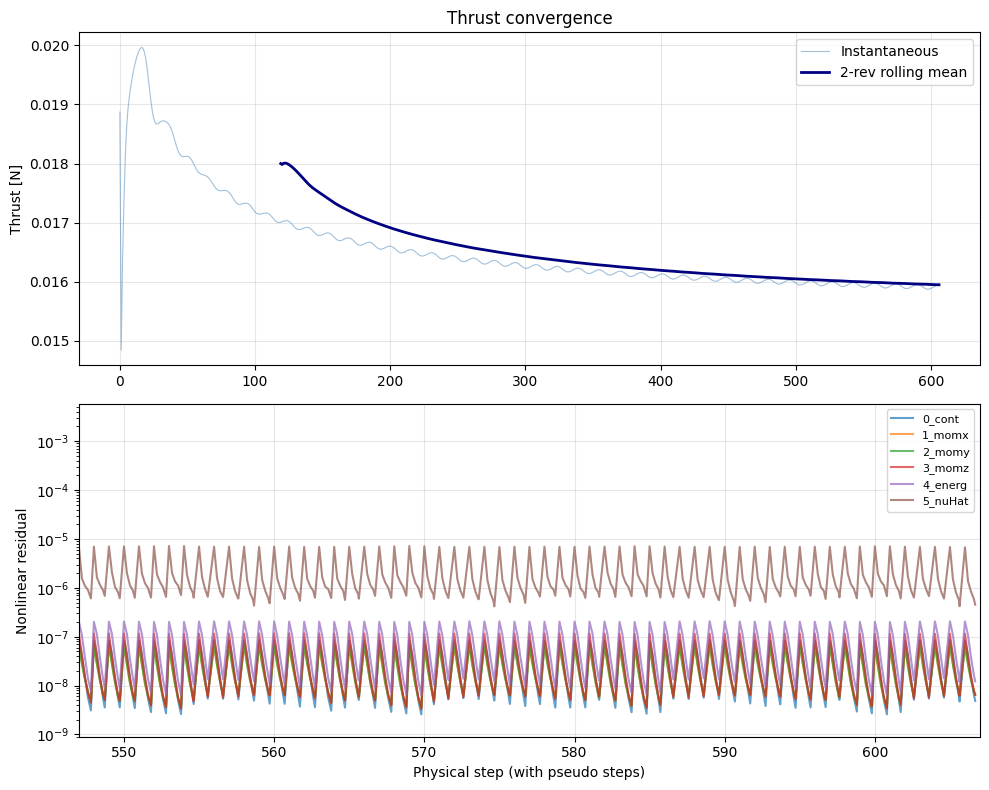

Simulation stopped at physical step 606 (10.1 revolutions)


In [9]:
case.wait()

# Reference quantities for dimensionalization
density = case.params.operating_condition.thermal_state.density
U_ref = case.params.operating_condition.velocity_magnitude
A_ref = case.params.reference_geometry.area
q = 0.5 * float(density) * float(U_ref) ** 2 * float(A_ref)

# Thrust monitors
thrust_monitor_mean = case.results.custom_forces["thrust_monitor_moving_statistic"].as_dataframe()
thrust_monitor_mean["Thrust_mean [N]"] = thrust_monitor_mean["totalCFz_mean"]
thrust_monitor_mean_step = thrust_monitor_mean["end_index"]
thrust_monitor = case.results.custom_forces["thrust_monitor"].as_dataframe()
thrust_monitor["Thrust [N]"] = thrust_monitor["totalCFz"]
thrust_monitor_step = thrust_monitor["physical_step"]

# --- Plot ---
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=False)

axes[0].plot(
    thrust_monitor["physical_step"],
    thrust_monitor["Thrust [N]"],
    color="steelblue",
    alpha=0.5,
    linewidth=0.8,
    label="Instantaneous",
)
axes[0].plot(
    thrust_monitor_mean["end_index"],
    thrust_monitor_mean["Thrust_mean [N]"],
    color="navy",
    linewidth=2,
    label=f"{revs_for_mean}-rev rolling mean",
)
axes[0].set_ylabel("Thrust [N]")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_title("Thrust convergence")

# Residuals: include pseudo steps, show only last revolution (via x limit)
final_step = thrust_monitor["physical_step"].iloc[-1]
non_linear = case.results.nonlinear_residuals.as_dataframe()
nl = non_linear.copy()
max_ps = nl["pseudo_step"].max() + 1
nl["step_with_pseudo"] = nl["physical_step"] + nl["pseudo_step"] / max_ps
for col in ["0_cont", "1_momx", "2_momy", "3_momz", "4_energ", "5_nuHat"]:
    if col in nl.columns:
        axes[1].semilogy(nl["step_with_pseudo"], nl[col], label=col, alpha=0.7)
axes[1].set_xlim(final_step - steps_per_rev + 1, final_step + 1)
axes[1].set_xlabel("Physical step (with pseudo steps)")
axes[1].set_ylabel("Nonlinear residual")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(
    f"Simulation stopped at physical step {final_step} "
    f"({final_step / steps_per_rev:.1f} revolutions)"
)